In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')

In [3]:
df2 = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')

In [4]:
df.sample(5)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
377649,377649,24.0,NaN,3.45,2.30,2.86,8.09,98.0,107.0,12.92,Other,High,Yes,1
333408,333408,18.0,4.02,1.77,1.43,0.31,8.82,80.0,150.0,NaN,Other,Low,No,0
498468,498468,34.0,12.39,5.43,2.69,3.66,7.30,110.0,127.0,12.38,Male,High,No,1
127314,127314,27.0,8.72,4.36,2.71,0.75,7.88,57.0,71.0,10.10,Male,Low,Yes,1
483319,483319,20.0,5.22,NaN,1.81,2.18,6.44,172.0,175.0,NaN,Male,Medium,No,0


In [5]:
X = df.drop(columns = ['id','addicted_label'])
Y = df['addicted_label']
ID = df['id']

In [6]:
# X_Numerical['screen_time_vs_age_group'] = (
#     df.groupby(pd.cut(df['age'], bins=5), observed=True)['daily_screen_time_hours']
#       .transform(lambda x: x - x.mean())
# )

# X_Numerical['screen_time_vs_stress_group'] = (
#     df.groupby('stress_level', observed=True)['daily_screen_time_hours']
#       .transform(lambda x: x - x.mean())
# )

In [7]:
# df['screen_time_vs_stress_group'].isna().sum()

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test,id_train,id_test = train_test_split(X,Y,ID,test_size = 0.2,random_state = 42)

In [9]:
X_Numerical = X_train.drop(columns = ['gender','stress_level','academic_work_impact'])
X_Categorical = X_train[['gender','stress_level','academic_work_impact']]

In [10]:
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import KNNImputer
# from sklearn.impute import SimpleImputer
# from sklearn.base import BaseEstimator, TransformerMixin

# #VBC
# class RandomSampleImputer(BaseEstimator, TransformerMixin):
#     def __init__(self, random_state=None):
#         self.random_state = random_state

#     def fit(self, X, y=None):
#         X = pd.DataFrame(X)
        
#         self.fill_values_ = {col: X[col].dropna() for col in X.columns}
#         self.feature_names_in_ = np.array(X.columns, dtype=object)
        
#         return self

#     def transform(self, X):
#         X = pd.DataFrame(X).copy()
        
#         for col in X.columns:
#             n_missing = X[col].isnull().sum()
            
#             if n_missing > 0:
#                 sampled = self.fill_values_[col].sample(
#                     n_missing, replace=True, random_state=self.random_state
#                 ).values
                
#                 X.loc[X[col].isnull(), col] = sampled
                
#         return X.values

#     def get_feature_names_out(self, input_features=None):
        
#         if input_features is not None:
#             return np.array(input_features, dtype=object)
            
#         return self.feature_names_in_

# trf1 = ColumnTransformer([
#     ('Imputed', RandomSampleImputer(random_state = 42), [0,1,2,3,4,5,6,7,8]),
    
# ],remainder = 'passthrough')

In [11]:
# T_Data = trf1.fit_transform(X_Numerical)

# columns = trf1.get_feature_names_out()
# clean_columns = [c.split('__')[-1] for c in columns]

# df_Data1 = pd.DataFrame(T_Data, columns=clean_columns, index=X_Numerical.index)

In [12]:
# df_Data1.sample(5)

In [13]:
# #PLOTTING THE DATA

# fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# axes = axes.flatten()

# j = 0
# for i in clean_columns:
    
#     sns.distplot(df_Data1[i], ax=axes[j])
#     axes[j].set_title(i.replace('_',' ').title())
#     j += 1

# axes[9].set_visible(False)
# plt.tight_layout()
# plt.show()

In [14]:
# df_Data1['weekly_screen_time'] = df_Data1['daily_screen_time_hours'] * 5 + df_Data1['weekend_screen_time']
# df_Data1['weekend_weekday_ratio'] = df_Data1['weekend_screen_time'] / (df_Data1['daily_screen_time_hours'] + 1e-5)
# df_Data1['social_media_share'] = df_Data1['social_media_hours'] / (df_Data1['daily_screen_time_hours'] + 1e-5)
# df_Data1['gaming_share'] = df_Data1['gaming_hours'] / (df_Data1['daily_screen_time_hours'] + 1e-5)
# df_Data1['work_share'] = df_Data1['work_study_hours'] / (df_Data1['daily_screen_time_hours'] + 1e-5)
# df_Data1['weekend_share_of_week'] = df_Data1['weekend_screen_time'] / (df_Data1['weekly_screen_time'] + 1e-5)
# df_Data1['notification_response_rate'] = df_Data1['app_opens_per_day'] / (df_Data1['notifications_per_day'] + 1e-5)

In [15]:
# df_Data1.sample(5)

In [16]:
# df_Data1.skew()

In [17]:
# cols = ['age','daily_screen_time_hours','social_media_hours','gaming_hours','work_study_hours','sleep_hours','notifications_per_day',
#         'app_opens_per_day','weekend_screen_time','weekly_screen_time',
#         'weekend_weekday_ratio','social_media_share', 'gaming_share','work_share','weekend_share_of_week',
#         'notification_response_rate']

In [18]:
# #PLOTTING THE DATA

# fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# axes = axes.flatten()

# j = 0
# for i in cols:
    
#     sns.distplot(df_Data1[i], ax=axes[j])
#     axes[j].set_title(i.replace('_',' ').title())
#     j += 1

# plt.tight_layout()
# plt.show()

# TRIMMING

In [19]:
# ratio_cols = [
#     'weekend_weekday_ratio', 'social_media_share', 'gaming_share',
#     'work_share', 'weekend_share_of_week', 'notification_response_rate'
# ]

# for i in ratio_cols:
#     lower = df_Data1[i].quantile(0.01)
#     upper = df_Data1[i].quantile(0.99)
#     df_Data1 = df_Data1[(df_Data1[i] >= lower) & (df_Data1[i] <= upper)]

# CLIPPING

In [20]:
# df_Data1['weekend_weekday_ratio'] = df_Data1['weekend_weekday_ratio'].clip(upper=df_Data1['weekend_weekday_ratio'].quantile(0.99))
# df_Data1['social_media_share'] = df_Data1['social_media_share'].clip(upper=df_Data1['social_media_share'].quantile(0.99))
# df_Data1['gaming_share'] = df_Data1['gaming_share'].clip(upper=df_Data1['gaming_share'].quantile(0.99))
# df_Data1['work_share'] = df_Data1['work_share'].clip(upper=df_Data1['work_share'].quantile(0.99))
# df_Data1['weekend_share_of_week'] = df_Data1['weekend_share_of_week'].clip(upper=df_Data1['weekend_share_of_week'].quantile(0.99))
# df_Data1['notification_response_rate'] = df_Data1['notification_response_rate'].clip(upper=df_Data1['notification_response_rate'].quantile(0.99))

In [21]:
# df_Data1.skew()

# # age                          -0.036825
# # daily_screen_time_hours      -0.131210
# # social_media_hours            0.467749
# # gaming_hours                  0.543498
# # work_study_hours              0.564907
# # sleep_hours                  -0.005907
# # notifications_per_day        -0.207069
# # app_opens_per_day            -0.126561
# # weekend_screen_time          -0.065266
# # weekly_screen_time           -0.127280
# # weekend_weekday_ratio         6.874240
# # social_media_share            5.440595
# # gaming_share                  4.790129
# # work_share                    5.798425
# # weekend_share_of_week         1.896602
# # notification_response_rate    2.960112

# #capping
# # age                          -0.036825
# # daily_screen_time_hours      -0.131210
# # social_media_hours            0.467749
# # gaming_hours                  0.543498
# # work_study_hours              0.564907
# # sleep_hours                  -0.005907
# # notifications_per_day        -0.207069
# # app_opens_per_day            -0.126561
# # weekend_screen_time          -0.065266
# # weekly_screen_time           -0.127280
# # weekend_weekday_ratio         2.117666
# # social_media_share            1.175386
# # gaming_share                  0.894011
# # work_share                    0.841802
# # weekend_share_of_week         1.271004
# # notification_response_rate    2.535534

In [22]:
# df_Data1.sample()

In [23]:
# from sklearn.preprocessing import FunctionTransformer
# from sklearn.compose import ColumnTransformer

# def cap_outliers(X):
#     X = np.asarray(X, dtype=float).copy() 
#     col = X[:, 0].astype(float)
#     q25, q75 = np.percentile(col, 25), np.percentile(col, 75)
#     iqr = q75 - q25
#     lower, upper = q25 - 1.5 * iqr, q75 + 1.5 * iqr
#     X[:, 0] = np.clip(col, lower, upper)
#     return X

# trf3 = ColumnTransformer([
#     ('Capped', FunctionTransformer(func=cap_outliers,feature_names_out='one-to-one',validate=True ), [2, 4])
# ], remainder='passthrough')

In [24]:
# T_Data = trf3.fit_transform(df_Data1)

# columns = trf3.get_feature_names_out()
# clean_columns = [c.split('__')[-1] for c in columns]

# df_Data3 = pd.DataFrame(T_Data, columns=clean_columns, index=X_Numerical.index)

In [25]:
# df_Data3.skew()

In [26]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler

# trf4 = ColumnTransformer([
#     ('Scaled',StandardScaler(),[1,3,5,7,8,9,10,11,12]), # Originally 6 , 7.
#     # Dont change 1(WSH) and 3(DSTH) , significant decrease in skewness
    
#     ('scale',MinMaxScaler(),[6])
# ], remainder ='passthrough')

In [27]:
# T_Data = trf4.fit_transform(df_Data1)
# columns = trf4.get_feature_names_out()
# clean_columns = [c.split('__')[-1] for c in columns]

# df_Data4 = pd.DataFrame(T_Data, columns=clean_columns, index=X_Numerical.index)

In [28]:
# #PLOTTING THE DATA

# fig, axes = plt.subplots(4, 3, figsize=(16, 16))

# axes = axes.flatten()

# j = 0
# for i in cols:
    
#     sns.distplot(df_Data4[i], ax=axes[j])
#     axes[j].set_title(i.replace('_',' ').title())
#     j += 1

# axes[9].set_visible(False)
# plt.tight_layout()
# plt.show()

In [29]:
# df_Data4.sample()

In [30]:
# # YES NPD .BETTER ONE FOR NOW

# from sklearn.preprocessing import FunctionTransformer
# from sklearn.preprocessing import PowerTransformer

# trf5 = ColumnTransformer([
#     #('transform',FunctionTransformer(func = np.log1p,feature_names_out = 'one-to-one'),['gaming_hours',]), # GH NPD
#     #('transformee',FunctionTransformer(func = np.sqrt,feature_names_out = 'one-to-one'),['social_media_hours']), # SMH
#     ('transformed', PowerTransformer(method = 'yeo-johnson', standardize = False),[0,1,2,3,4,5,6,7,8,9,10,12]) # REST EXCEPT AGE
# ],remainder = 'passthrough')

In [31]:
# T_Data = trf5.fit_transform(df_Data4)

# columns = trf5.get_feature_names_out()
# clean_columns = [c.split('__')[-1] for c in columns]

# df_Data5 = pd.DataFrame(T_Data, columns=clean_columns, index=X_Numerical.index)

In [32]:
# df_Data5.skew()

In [33]:
# #PLOTTING THE DATA

# fig, axes = plt.subplots(4, 3, figsize=(16, 16))

# axes = axes.flatten()

# j = 0
# for i in cols:
    
#     sns.distplot(df_Data5[i], ax=axes[j])
#     axes[j].set_title(i.replace('_',' ').title())
#     j += 1

# axes[9].set_visible(False)
# plt.tight_layout()
# plt.show()

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd


class RandomSampleImputer(BaseEstimator, TransformerMixin):
    def __init__(self, random_state=None):
        self.random_state = random_state

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.fill_values_ = {col: X[col].dropna() for col in X.columns}
        self.feature_names_in_ = np.array(X.columns, dtype=object)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            n_missing = X[col].isnull().sum()
            if n_missing > 0:
                sampled = self.fill_values_[col].sample(
                    n_missing, replace=True, random_state=self.random_state
                ).values
                X.loc[X[col].isnull(), col] = sampled
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features, dtype=object)
        return self.feature_names_in_


trf1 = ColumnTransformer([
    ('Imputed', RandomSampleImputer(random_state=42), [0, 1, 2, 3, 4, 5, 6, 7, 8]),
], remainder='passthrough')
# Output order unchanged: 0..8


def add_engineered_features(X):
    X = np.asarray(X, dtype=float).copy()
    daily_screen_time_hours = X[:, 1]
    social_media_hours = X[:, 2]
    gaming_hours = X[:, 3]
    work_study_hours = X[:, 4]
    notifications_per_day = X[:, 6]
    app_opens_per_day = X[:, 7]
    weekend_screen_time = X[:, 8]

    weekly_screen_time = daily_screen_time_hours * 5 + weekend_screen_time
    weekend_weekday_ratio = weekend_screen_time / (daily_screen_time_hours + 1e-5)
    social_media_share = social_media_hours / (daily_screen_time_hours + 1e-5)
    gaming_share = gaming_hours / (daily_screen_time_hours + 1e-5)
    work_share = work_study_hours / (daily_screen_time_hours + 1e-5)
    weekend_share_of_week = weekend_screen_time / (weekly_screen_time + 1e-5)
    # NEW: how many app opens per notification received — engagement responsiveness
    notification_response_rate = app_opens_per_day / (notifications_per_day + 1e-5)

    new_cols = np.column_stack([
        weekly_screen_time,           # -> 9
        weekend_weekday_ratio,        # -> 10
        social_media_share,           # -> 11
        gaming_share,                 # -> 12
        work_share,                   # -> 13
        weekend_share_of_week,        # -> 14
        notification_response_rate,   # -> 15
    ])
    return np.hstack([X, new_cols])
    # Output: original 9 cols (0-8) + 7 new cols (9-15) = 16 total


def add_engineered_features_names(input_features=None):
    base = list(input_features) if input_features is not None else [
        'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
        'work_study_hours', 'sleep_hours', 'notifications_per_day',
        'app_opens_per_day', 'weekend_screen_time'
    ]
    return np.array(base + [
        'weekly_screen_time', 'weekend_weekday_ratio',
        'social_media_share', 'gaming_share', 'work_share', 'weekend_share_of_week',
        'notification_response_rate'
    ], dtype=object)


trf2 = FunctionTransformer(
    func=add_engineered_features,
    feature_names_out=add_engineered_features_names,
    validate=True
)


def cap_outliers(X):
    """IQR-based two-sided cap (unchanged)."""
    X = np.asarray(X, dtype=float).copy()
    col = X[:, 0].astype(float)
    q25, q75 = np.percentile(col, 25), np.percentile(col, 75)
    iqr = q75 - q25
    lower, upper = q25 - 1.5 * iqr, q75 + 1.5 * iqr
    X[:, 0] = np.clip(col, lower, upper)
    return X


def cap_outliers_99(X):
    """Upper-tail cap at the 99th percentile, applied independently to EACH
    column passed in."""
    X = np.asarray(X, dtype=float).copy()
    for i in range(X.shape[1]):
        col = X[:, i]
        upper = np.percentile(col, 99)
        X[:, i] = np.clip(col, None, upper)
    return X


trf3 = ColumnTransformer([
    ('Capped', FunctionTransformer(func=cap_outliers, feature_names_out='one-to-one', validate=True), [2, 4]),
    # [2, 4] = social_media_hours, work_study_hours

    ('Capeed', FunctionTransformer(func=cap_outliers_99, feature_names_out='one-to-one', validate=True),
     [10, 11, 12, 13, 14, 15]),
],remainder = 'passthrough')

# def trim_outliers_array(X, y, ratio_col_indices, lower_q=0.01, upper_q=0.99):
#     X = np.asarray(X, dtype=float)
#     mask = np.ones(X.shape[0], dtype=bool)
#     for i in ratio_col_indices:
#         col = X[:, i]
#         lower, upper = np.percentile(col, lower_q * 100), np.percentile(col, upper_q * 100)
#         mask &= (col >= lower) & (col <= upper)
#     return X[mask], np.asarray(y)[mask]

# trf3 = FunctionSampler(func=trim_outliers_array, kw_args={'ratio_col_indices': [10,11,12,13,14,15]})


trf4 = ColumnTransformer([
    ('Scaled', StandardScaler(), [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15]),
], remainder='passthrough')


trf5 = ColumnTransformer([
    ('transformed', PowerTransformer(method='yeo-johnson', standardize=False),
     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]),  # REST EXCEPT AGE (15)
], remainder='passthrough')


Numerical_Pipeline = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('trf3', trf3),
    ('trf4', trf4),
    ('trf5', trf5),
])

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,MissingIndicator
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

trfC1 = ColumnTransformer([
    ('Imputed',SimpleImputer(strategy='constant',fill_value = 'Missing'),['gender','stress_level','academic_work_impact']),
], remainder = 'passthrough')



trfC2 = ColumnTransformer([
    ('OE', OrdinalEncoder(categories = [['Missing','Low','Medium','High',]]),[1]),
   #('OE', OrdinalEncoder(categories = [['Missing','Male','Female','Other'],['Missing','Low','Medium','High',],['Missing','Yes','No']]),[0,1,2]),
    ('OHE', OneHotEncoder(drop = 'first',sparse_output = False, dtype=np.int32),[0,2]),
])

Categorical_Pipeline = Pipeline([
    ('trfC1',trfC1),
    ('trfC2',trfC2),
])

h

In [36]:
# X_train.sample()

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.svm import SVC

numeric_cols = [
    'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day','weekend_screen_time']

categorical_cols = ['gender', 'stress_level', 'academic_work_impact']

preprocessor = ColumnTransformer([
    ('num', Numerical_Pipeline, numeric_cols),
   ('cat', Categorical_Pipeline, categorical_cols)
])

# model = XGBClassifier(
#         n_estimators=400,
#         learning_rate=0.1,
#         max_depth=100,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_alpha=0,      # L1 regularization
#         reg_lambda=1,     # L2 regularization
#         eval_metric='logloss'
#     )

# # model = SVC(kernel='linear', C=1)
# # model = RandomForestClassifier(n_estimators=500, random_state=42)

# pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('Model', model)
# ])


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score
 
import optuna
from xgboost import XGBClassifier


X = X_train   # <-- replace
y = y_train   # <-- replace

 
def objective(trial):
    xgb_params = {
        'objective': 'binary:logistic',      # change if multiclass / regression
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': 1, # avoid oversubscription with parallel folds


        
 
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }
 
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('Model', XGBClassifier(**xgb_params)),
    ])
 
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=5)
 
    return scores.mean()

if __name__ == '__main__':
    
    if X is None or y is None:
        raise ValueError("Load X and y before running the study (see section 5).")
 
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=15) #, timeout=3600)
 
    print("Best AUC:", study.best_value)
    print("Best params:", study.best_params)


[I 2026-08-15 07:43:54,208] A new study created in memory with name: no-name-81de2f98-6ee1-4c08-96d7-39205bc30269
[I 2026-08-15 07:44:22,509] Trial 0 finished with value: 0.9175589979632927 and parameters: {'n_estimators': 173, 'max_depth': 4, 'learning_rate': 0.03654207621202758, 'min_child_weight': 9, 'gamma': 3.321251991450676, 'reg_alpha': 1.736490708698199e-06, 'reg_lambda': 0.005263565891178118, 'subsample': 0.9197174079782794, 'colsample_bytree': 0.5528407978029315}. Best is trial 0 with value: 0.9175589979632927.
[I 2026-08-15 07:45:25,311] Trial 1 finished with value: 0.9330688467222338 and parameters: {'n_estimators': 445, 'max_depth': 8, 'learning_rate': 0.01810403395062414, 'min_child_weight': 16, 'gamma': 1.7045783991077306, 'reg_alpha': 1.8436230994245607e-05, 'reg_lambda': 5.408450575500186, 'subsample': 0.6365340067882705, 'colsample_bytree': 0.9095837781286594}. Best is trial 1 with value: 0.9330688467222338.
[I 2026-08-15 07:45:59,179] Trial 2 finished with value: 0.9

Best AUC: 0.9448512517756716
Best params: {'n_estimators': 640, 'max_depth': 9, 'learning_rate': 0.04639881941336001, 'min_child_weight': 13, 'gamma': 0.8359119307777383, 'reg_alpha': 0.23567697996112508, 'reg_lambda': 3.577261621797046e-05, 'subsample': 0.6041664559059408, 'colsample_bytree': 0.8764462524649543}


In [39]:
best_params = study.best_params
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
})

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('Model', XGBClassifier(**best_params)),
])
final_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('trf1',
                                                                   ColumnTransformer(remainder='passthrough',
                                                                                     transformers=[('Imputed',
                                                                                                    RandomSampleImputer(random_state=42),
                                                                                                    [0,
                                                                                                     1,
                                                                                                     2,
                                                                                                     3,
                                                                                                     4,
                                                                                                     5,
                                                                                                     6,
                                                                                                     7,
                                                                                                     8])])),
                                                                  ('trf2',
                                                                   FunctionTransformer(feature_names_out=<function add_engineered_features_names at 0x7fcbe2fb5bc0>,
                                                                                       func=<function add_enginee...
                               gamma=0.8359119307777383, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.04639881941336001, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=9,
                               max_leaves=None, min_child_weight=13,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=640, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [40]:

# final_pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('Model', XGBClassifier(n_estimators= 999, max_depth= 7, learning_rate= 0.05918682319000081, 
#     min_child_weight= 15, gamma= 2.499005900584807, reg_alpha= 1.3692526972159991e-06, reg_lambda= 0.07945013259942392, subsample= 0.6837747840841361, colsample_bytree=0.677291222496982)),
# ])
# final_pipe.fit(X_train, y_train)

In [41]:
y_pred = final_pipe.predict(X_test)

In [42]:
y_pred_proba = final_pipe.predict_proba(X_test)[:, 1] 

In [43]:
from sklearn.metrics import roc_auc_score

# Wrong — using hard predictions
# gives 0s and 1s
auc = roc_auc_score(y_test, y_pred)    # technically works, but is a poor/misleading metric
print(auc)
print(" ")
# Right — using predicted probabilities
 # probability of the positive class
auc = roc_auc_score(y_test, y_pred_proba)
print(auc)# correct usage

0.8453058293873709
 
0.9450860380867687


In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(final_pipe, X_train, y_train, cv=5, scoring='roc_auc')
print(scores.mean(), scores.std())

0.9450742748602158 0.00036422388973607724


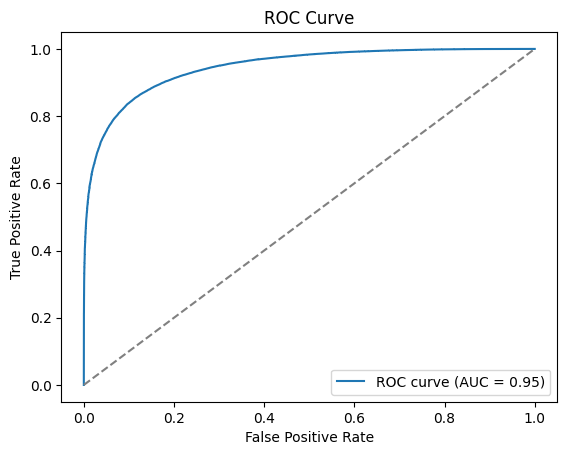

In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

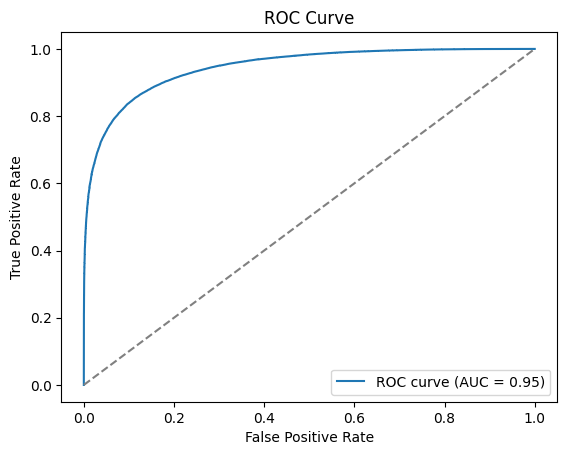

In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [47]:
# 5   0.244180   weekly_screen_time
# 4   0.154600   weekend_screen_time
# 1   0.136537   daily_screen_time_hours
# 10  0.104045   social_media_hours
# 6   0.055729   unproductive_hours
# 9   0.050770   notifications_per_day
# 7   0.046410   weekend_weekday_ratio
# 3   0.044917   app_opens_per_day
# 0   0.029950   work_study_hours
# 11  0.028777   gaming_hours
# 12  0.016781   age
# 2   0.014813   sleep_hours
# 14  0.011677   gender_Male
# 8   0.011334   work_sleep_balance
# 15  0.010760   gender_Missing
# 13  0.010522   stress_level
# 16  0.009953   gender_Other
# 17  0.009207   academic_work_impact_No
# 18  0.009039   academic_work_impact_Yes

In [48]:
# Get feature names from the full preprocessing pipeline

importances = final_pipe.named_steps['Model'].feature_importances_

# clean_names = [
#     'gaming_hours', 'social_media_hours', 'work_study_hours', 'daily_screen_time_hours',
#     'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'age',
#     'stress_level', 'gender_Female', 'gender_Male', 'gender_Other',
#      'academic_work_impact_No', 'academic_work_impact_Yes' # 'gender_Missing','academic_work_impact_Missing'
# ]

importance_df = pd.DataFrame({
    #'feature': clean_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df)

    importance
14    0.406470
8     0.092184
0     0.072664
13    0.062486
3     0.061847
11    0.043148
12    0.039917
5     0.022654
2     0.021492
6     0.020049
4     0.018690
1     0.017512
9     0.015584
15    0.014700
10    0.013911
18    0.013525
17    0.011741
7     0.011223
16    0.010909
19    0.010638
20    0.009359
21    0.009297
